# Import libraries

In [21]:
import os
import warnings
import logging
import pandas as pd
import matplotlib.pyplot as plt
from oemof.solph import (Bus, EnergySystem, Flow, Model, create_time_index, processing)
from oemof.solph.components import (Sink, Source, Converter, GenericStorage)  
from oemof.solph import EnergySystem
from oemof.solph import views
import oemof.solph as solph

## 1.1 Create the energy system

In [22]:
from oemof.solph import NonConvex

# read the input data file
filename = r"OEMOF_files/Step3-correct.csv"
data = pd.read_csv(filename, delimiter=";")


# specifying the solver
solver = "gurobi"
solver_verbose = False

# Create energy system
datetimeindex = create_time_index(2022, number=len(data)) # By default, the function creates an hourly index for one year.
energysystem = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)

# Add components to the energy system
# Buses
electrical_bus = Bus(label="electrical_bus") # Electricity bus
thermal_bus = Bus(label="thermal_bus") # Heat bus
gas_bus = Bus(label="gas_bus") # Natural gas bus
biogas_bus = Bus(label="biogas_bus") # Natural gas bus

energysystem.add(electrical_bus, thermal_bus, gas_bus, biogas_bus)




# Excess electricity sink
energysystem.add(
    Sink(
        label="excess_electricity",
        inputs={electrical_bus: Flow(variable_costs=data["electricity_price"] * -1)}
    )
)

# Gas source with cost from gas + CO2
energysystem.add(
    Source(label="natural_gas",outputs={gas_bus: Flow(variable_costs=data["gas_price"] )})
                )



# Gas source with cost biogas
energysystem.add(
    Source(label="bio_gas",outputs={biogas_bus: Flow(variable_costs=60.0)})
                )

# Grid electricity source
energysystem.add(
    Source(label="electricity_grid",outputs={electrical_bus: Flow(variable_costs=data["electricity_price"])})
                )

# Thermal demand sink
energysystem.add(
    Sink(
        label="thermal_demand",
        inputs={thermal_bus: Flow(
            nominal_value=3.50146517,
            fix=data["thermal_demand"]  #/max(data["thermal_demand"])
        )},
    )
)


# natural gas CHP (0.85MW)
energysystem.add(
    Converter(
        label="chp_gas",
        inputs={gas_bus: Flow()},
        outputs={
            electrical_bus: Flow(),
            thermal_bus: Flow(nominal_value=0.85,
                              min=0.1,
                              variable_costs=0.29)
        },
        conversion_factors={electrical_bus: 0.36, thermal_bus: 0.54}
    )
)

# biomass CHP (0.6MW)
energysystem.add(
    Converter(
        label="chp_bio",
        inputs={biogas_bus: Flow()}, 
        outputs={
            electrical_bus: Flow(                              
                                 ),
            thermal_bus: Flow(nominal_value=0.6, 
                              min=0.1,
                              variable_costs=2.5)
        },
        conversion_factors={electrical_bus: 0.40, thermal_bus: 0.42}
    )
)


# Electric boiler (1.1MW)
energysystem.add(
    Converter(
        label="electric_boiler",
        inputs={electrical_bus: Flow()},
        outputs={thermal_bus: Flow(nominal_value=1.1, variable_costs=0.5)},
        conversion_factors={thermal_bus: 0.99} 
    )
)


# Heat Pump 0.79 MW
energysystem.add(
    Converter(
        label="heat_pump_0.79_MW",
        inputs={electrical_bus: Flow()},
        outputs={thermal_bus: Flow(nominal_value=0.79, variable_costs=1.5)},
        conversion_factors={thermal_bus: 3.5} 
    )
)

# Heat Pump 0.94 MW
energysystem.add(
    Converter(
        label="heat_pump_0.94_MW",
        inputs={electrical_bus: Flow()},
        outputs={thermal_bus: Flow(nominal_value=0.94, variable_costs=1.7)},
        conversion_factors={thermal_bus: 3.5} 
    )
)




## 1.2 Build and solve model

In [23]:
model = Model(energysystem)


logging.info("Solving the optimization problem.")
model.solve(
    solver='gurobi',
    solve_kwargs={"tee": solver_verbose},
    options={"mip_gap": 0.02}   # 2% relative MIP gap
)

'''
This returns a dictionary containing time series and scalar results for all components (buses, converters, sources, etc.).
Or view results for a specific node (for example, a bus).
'''

# Process results
energysystem.results["main"] = processing.results(model)
energysystem.results["meta"] = processing.meta_results(model)

# Save results to file
output_file = os.path.join(os.getcwd(), "Outputs/results.oemof")

energysystem.dump(os.getcwd(), "Outputs/results.oemof")

logging.info("Results have been dumped.")

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\oemof\network\energy_system.py:256: FutureWarning: Parameter 'dpath' will be removed in a future version. You can give the directory as part of the filename and set 'consider_dpath' to False to suppress this waring.
  warnings.warn(


## 1.3 Results

In [24]:
energysystem.results

results = energysystem.results["main"]

# get all variables of a specific component/bus
thermal_bus = views.node(results, "thermal_bus")

### Analyse thermal node

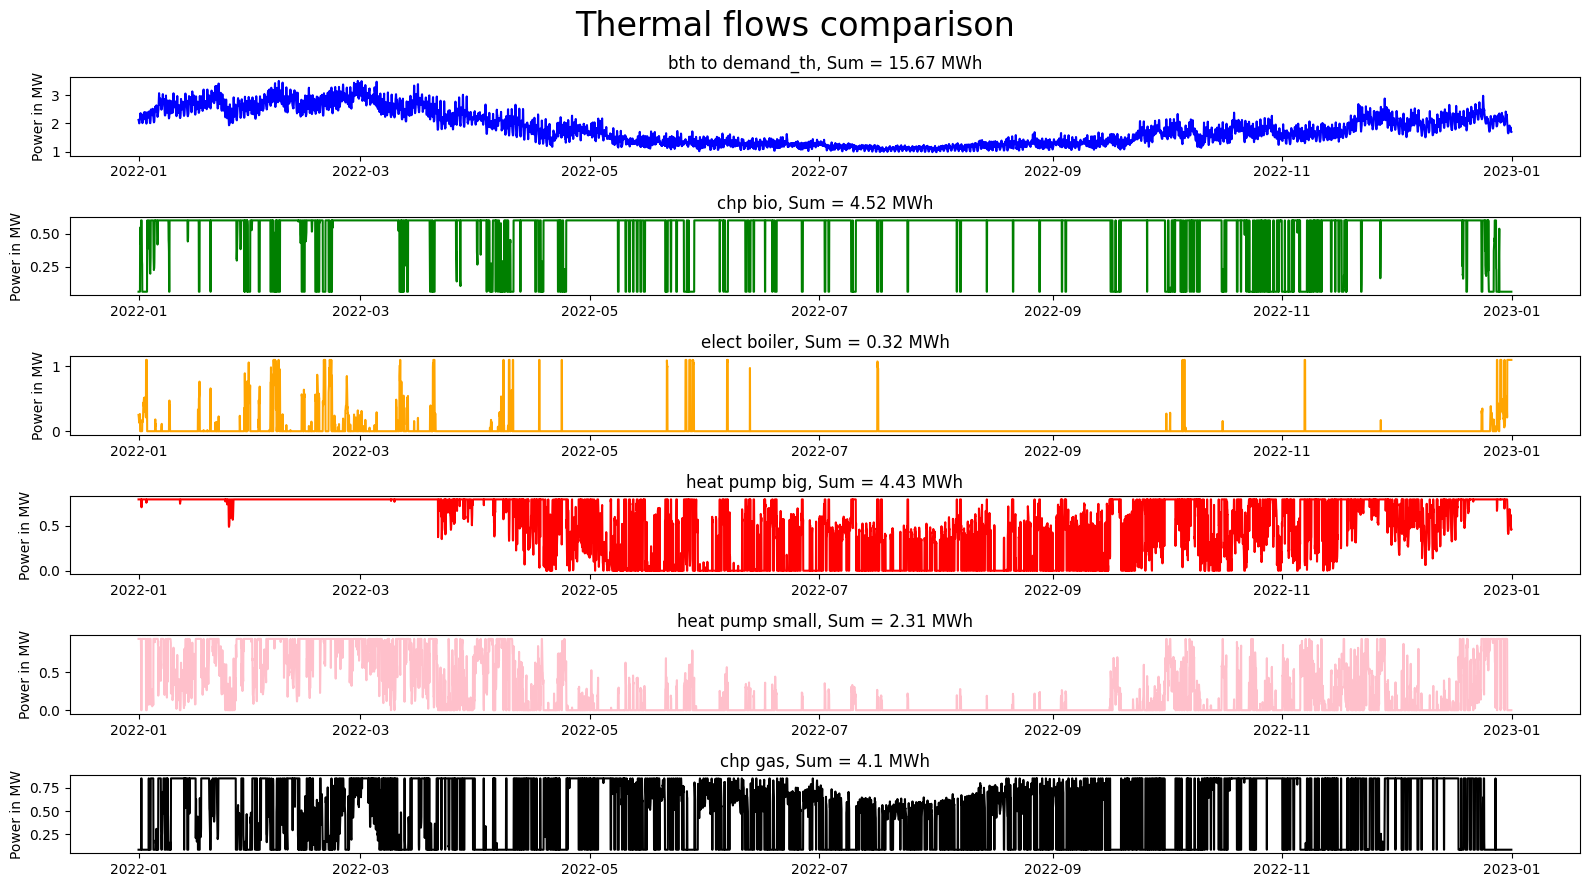

In [25]:
Sum_th_demand = thermal_bus["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')].sum()
Sum_th_prod_chp_gas = thermal_bus["sequences"][(('chp_gas', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_chp_bio = thermal_bus["sequences"][(('chp_bio', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_boiler = thermal_bus["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_hp_big = thermal_bus["sequences"][(('heat_pump_0.79_MW', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_hp_small = thermal_bus["sequences"][(('heat_pump_0.94_MW', 'thermal_bus'), 'flow')].sum()

fig, axs = plt.subplots(6,figsize=(16, 9))
fig.suptitle('Thermal flows comparison', fontsize=24)
axs[0].plot(thermal_bus["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')], 'blue')
axs[0].set_title(f'bth to demand_th, Sum = {round(float(Sum_th_demand/1000), 2)} MWh')
axs[1].plot(thermal_bus["sequences"][(('chp_bio', 'thermal_bus'), 'flow')], 'green')
axs[1].set_title(f'chp bio, Sum = {round(float(Sum_th_prod_chp_bio/1000),2)} MWh')
axs[2].plot(thermal_bus["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')], 'orange')
axs[2].set_title(f'elect boiler, Sum = {round(float(Sum_th_prod_boiler/1000),2)} MWh')
axs[3].plot(thermal_bus["sequences"][(('heat_pump_0.79_MW', 'thermal_bus'), 'flow')], 'red')
axs[3].set_title(f'heat pump big, Sum = {round(float(Sum_th_prod_hp_big/1000),2)} MWh')
axs[4].plot(thermal_bus["sequences"][(('heat_pump_0.94_MW', 'thermal_bus'), 'flow')], 'pink')
axs[4].set_title(f'heat pump small, Sum = {round(float(Sum_th_prod_hp_small/1000),2)} MWh')
axs[5].plot(thermal_bus["sequences"][(('chp_gas', 'thermal_bus'), 'flow')], 'black')
axs[5].set_title(f'chp gas, Sum = {round(float(Sum_th_prod_chp_gas/1000),2)} MWh')

axs[0].set_ylabel('Power in MW')
axs[1].set_ylabel('Power in MW')
axs[2].set_ylabel('Power in MW')
axs[3].set_ylabel('Power in MW')
axs[4].set_ylabel('Power in MW')
axs[5].set_ylabel('Power in MW')


plt.tight_layout()
plt.show()

In [26]:
print("Total system cost [k€]:", model.objective()/1000)

Total system cost [k€]: 26.48529878000206


In [27]:
import pandas as pd

# ---------------------------------------------------------
# ACCESS RESULTS
# ---------------------------------------------------------
thermal_bus = views.node(results, "thermal_bus")
electrical_bus = views.node(results, "electrical_bus")

th_flows = thermal_bus["sequences"]
el_flows = electrical_bus["sequences"]

price_el = data["electricity_price"]
price_gas = data["gas_price"]
price_bio = 60.0  # fixed biogas price

# ---------------------------------------------------------
# CONVERSION FACTORS
# ---------------------------------------------------------
conv = {
    "chp_gas": {"th": 0.54, "el": 0.36},
    "chp_bio": {"th": 0.42, "el": 0.40},
    "electric_boiler": {"th": 0.99},
    "heat_pump_0.79_MW": {"th": 3.5},
    "heat_pump_0.94_MW": {"th": 3.5},
}

# ---------------------------------------------------------
# VARIABLE COSTS (€/MWh_th)
# ---------------------------------------------------------
var_costs = {
    "chp_gas": 0.29,
    "chp_bio": 2.5,
    "electric_boiler": 0.5,
    "heat_pump_0.79_MW": 1.5,
    "heat_pump_0.94_MW": 1.7,
}

# ---------------------------------------------------------
# FULL OPERATIONAL COST CALCULATION
# ---------------------------------------------------------
results_costs = {}

for comp in var_costs.keys():
    
    # thermal output
    th = th_flows[((comp, "thermal_bus"), "flow")]
    
    # fuel / electricity input
    if comp == "chp_gas":
        fuel_cost = 0
        fuel = th / conv[comp]["th"]
        for i in range(len(fuel)-1):
            fuel_cost += fuel[i] * price_gas[i]

        
        
    elif comp == "chp_bio":
        fuel = th / conv[comp]["th"]
        fuel_cost = (fuel * price_bio).sum()
        
    else:  # electric boiler & heat pumps
        fuel_cost = 0
        el = th / conv[comp]["th"]
        for i in range(len(el)-1):
            fuel_cost += el[i] * price_el[i]
    
    # variable O&M cost
    var_cost = (th * var_costs[comp]).sum()
    
    # total operational cost
    results_costs[comp] = {
        "Thermal production [MWh]": th.sum() / 1000,
        "Fuel / electricity cost [k€]": fuel_cost/1000,
        "Variable cost [k€]": var_cost/1000,
        "Total operational cost [k€]": fuel_cost/1000 + var_cost/1000
    }

# ---------------------------------------------------------
# CHP ELECTRICITY REVENUE
# ---------------------------------------------------------
chp_revenue = {}

for comp in ["chp_gas", "chp_bio"]:
    el_out = el_flows[((comp, "electrical_bus"), "flow")]
    revenue = 0
    for i in range(len(el_out)-1):
        revenue += el_out[i] * price_el[i]
    
    chp_revenue[comp] = {
        "Electricity sold [MWh]": el_out.sum() / 1000,
        "Electricity revenue [k€]": revenue/1000
    }

# ---------------------------------------------------------
# FINAL DATAFRAMES
# ---------------------------------------------------------
df_costs = pd.DataFrame(results_costs).T
df_revenue = pd.DataFrame(chp_revenue).T

print("\nFULL OPERATIONAL COSTS (INCLUDING FUEL & ELECTRICITY):\n")
display(df_costs.round(2))

print("\nCHP ELECTRICITY SALES:\n")
display(df_revenue.round(2))

print("\nTOTAL OPERATIONAL COSTS AFTER ELECTRICITY REVENUE:\n")
df_total = df_costs.copy()
for comp in ["chp_gas", "chp_bio"]:
    df_total.loc[comp, "Total operational cost [k€]"] -= df_revenue.loc[comp, "Electricity revenue [k€]"] 
display(df_total.round(2))

print("\nCOST PER MWH TH PRODUCED:\n")
df_cpmwh = df_total.copy()
for comp in df_cpmwh.index:
    df_cpmwh.loc[comp, "Cost per MWh_th [k€/MWh]"] = df_total.loc[comp, "Total operational cost [k€]"] / df_total.loc[comp, "Thermal production [MWh]"]
display(df_cpmwh.round(2))


C:\Users\PC\AppData\Local\Temp\ipykernel_11764\2120647312.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fuel_cost += fuel[i] * price_gas[i]
C:\Users\PC\AppData\Local\Temp\ipykernel_11764\2120647312.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fuel_cost += el[i] * price_el[i]
C:\Users\PC\AppData\Local\Temp\ipykernel_11764\2120647312.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  revenue += el_out[i] * price_el[i]


FULL OPERATIONAL COSTS (INCLUDING FUEL & ELECTRICITY):



,Thermal production [MWh],Fuel / electricity cost [k€],Variable cost [k€],Total operational cost [k€]
chp_gas,4.10,903.45,1.19,904.64
chp_bio,4.52,645.25,11.29,656.54
electric_boiler,0.32,9.41,0.16,9.56
heat_pump_0.79_MW,4.43,240.09,6.65,246.74
heat_pump_0.94_MW,2.31,94.23,3.93,98.16



CHP ELECTRICITY SALES:



,Electricity sold [MWh],Electricity revenue [k€]
chp_gas,2.73,752.98
chp_bio,4.30,1136.17



TOTAL OPERATIONAL COSTS AFTER ELECTRICITY REVENUE:



,Thermal production [MWh],Fuel / electricity cost [k€],Variable cost [k€],Total operational cost [k€]
chp_gas,4.10,903.45,1.19,151.66
chp_bio,4.52,645.25,11.29,-479.63
electric_boiler,0.32,9.41,0.16,9.56
heat_pump_0.79_MW,4.43,240.09,6.65,246.74
heat_pump_0.94_MW,2.31,94.23,3.93,98.16



COST PER MWH TH PRODUCED:



,Thermal production [MWh],Fuel / electricity cost [k€],Variable cost [k€],Total operational cost [k€],Cost per MWh_th [k€/MWh]
chp_gas,4.10,903.45,1.19,151.66,37.02
chp_bio,4.52,645.25,11.29,-479.63,-106.19
electric_boiler,0.32,9.41,0.16,9.56,30.13
heat_pump_0.79_MW,4.43,240.09,6.65,246.74,55.70
heat_pump_0.94_MW,2.31,94.23,3.93,98.16,42.42


In [28]:
#Total cost without electricity revenue
total_cost = df_costs["Total operational cost [k€]"].sum()
print("\nTotal operational cost without electricity revenue [k€]:", round(total_cost,2))


Total operational cost without electricity revenue [k€]: 1915.64
